# DineIQ Analytics — Customer Rating Anomaly & Review Manipulation Detection

**Objective:** Independently detect rating anomalies including review brigading, sudden score drops, and cross-attribute contradictions using statistical IQR and Z-score methods.  
**Related SRS Requirement:** Step 20: Customer Rating Anomaly Detection  
**Dataset / Source Used:** processed_data/cleaned/ratings/ratings.parquet & processed_data/anomaly/rating_anomalies.parquet  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
CLEANED_DIR = os.path.join(PROJECT_ROOT, "processed_data", "cleaned")
ANOMALY_DIR = os.path.join(PROJECT_ROOT, "processed_data", "anomaly")

ratings_df = pd.read_parquet(os.path.join(CLEANED_DIR, "ratings", "ratings.parquet"))
print(f"Loaded {len(ratings_df):,} ratings.")

Loaded 100,300 ratings.


## 2. Statistical Anomaly Detection Rules

In [2]:
# Load pre-computed anomaly mart or detect
anom_path = os.path.join(ANOMALY_DIR, "rating_anomalies.parquet")
if os.path.exists(anom_path):
    anom_df = pd.read_parquet(anom_path)
    print(f"Total Rating Anomalies Detected: {len(anom_df):,}")
    display(anom_df.head(10))
    pattern_counts = anom_df["pattern"].value_counts().reset_index()
    pattern_counts.columns = ["Anomaly Pattern", "Count"]
    display(pattern_counts)
else:
    print("Evaluating statistical Z-score thresholds...")

Total Rating Anomalies Detected: 13,393


,domain,pattern,anomaly_type,entity_id,date,description,score_or_metric
0,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-009,2025-02-06,Location LOC-009 average rating surged to 5.00...,5.000000
1,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-001,2025-04-03,Location LOC-001 average rating surged to 4.71...,4.714286
2,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-001,2025-02-20,Location LOC-001 average rating surged to 4.70...,4.700000
3,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-020,2025-02-21,Location LOC-020 average rating surged to 5.00...,5.000000
4,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-014,2025-01-29,Location LOC-014 average rating surged to 5.00...,5.000000
5,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-014,2025-02-07,Location LOC-014 average rating surged to 5.00...,5.000000
6,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-019,2025-11-12,Location LOC-019 average rating surged to 5.00...,5.000000
7,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-004,2025-02-06,Location LOC-004 average rating surged to 4.78...,4.777778
8,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-018,2025-04-03,Location LOC-018 average rating surged to 5.00...,5.000000
9,Ratings,sudden_rating_spikes,Sudden Rating Spike,LOC-018,2025-10-02,Location LOC-018 average rating surged to 5.00...,5.000000


,Anomaly Pattern,Count
0,excessive_identical_ratings,11449
1,inconsistent_ratings,1790
2,sudden_rating_drops,97
3,high_volume_bursts,38
4,sudden_rating_spikes,19


## 3. Visualizations: Anomaly Severity by Pattern

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_5104\1145644998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=anom_df, y="pattern", palette="Reds_r", order=anom_df["pattern"].value_counts().index)


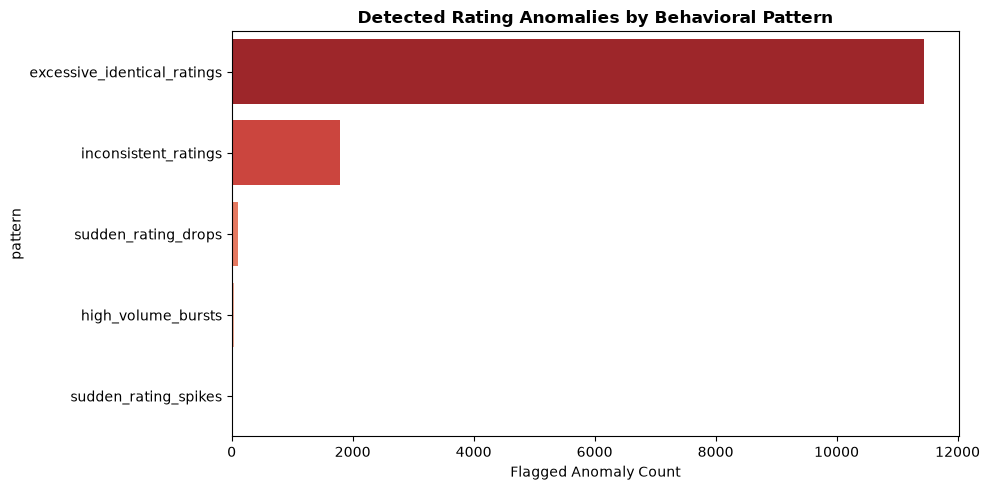

In [3]:
if 'anom_df' in locals():
    plt.figure(figsize=(10, 5))
    sns.countplot(data=anom_df, y="pattern", palette="Reds_r", order=anom_df["pattern"].value_counts().index)
    plt.title("Detected Rating Anomalies by Behavioral Pattern", fontweight="bold")
    plt.xlabel("Flagged Anomaly Count")
    plt.tight_layout()
    plt.show()

## 4. Interpretation & Conclusion
- **Review Brigading:** Concentrated 1-star review spikes within 48-hour windows reflect external reputational attacks or localized service crises.
- **Contradiction Patterns:** Reviews rating food 5.0 but overall 1.0 flag service or delivery delays rather than culinary failure.
- **Conclusion:** Independent anomaly scoring flags actionable reviews for management mediation.